In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt


ems = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRxqoe_H3mxsXhdlp3R7PZ5Zw5tLCB4sxDARLMNYUgMcFqYw3WfCnEXN5hFIi99hxG3WTRi-FxemwGK/pub?output=csv"

ems_data = pd.read_csv(ems)

ems_data.head()

#ems_data.columns



,INCIDENT_DATETIME,INITIAL_CALL_TYPE,INITIAL_SEVERITY_LEVEL_CODE,FINAL_CALL_TYPE,FINAL_SEVERITY_LEVEL_CODE,FIRST_ASSIGNMENT_DATETIME,VALID_DISPATCH_RSPNS_TIME_INDC,DISPATCH_RESPONSE_SECONDS_QY,FIRST_ACTIVATION_DATETIME,FIRST_ON_SCENE_DATETIME,VALID_INCIDENT_RSPNS_TIME_INDC,INCIDENT_RESPONSE_SECONDS_QY,INCIDENT_TRAVEL_TM_SECONDS_QY,FIRST_TO_HOSP_DATETIME,FIRST_HOSP_ARRIVAL_DATETIME,INCIDENT_CLOSE_DATETIME,HELD_INDICATOR,INCIDENT_DISPOSITION_CODE,BOROUGH
0,07/01/2025 12:00:14 AM,ABDPN,5,ABDPN,5,07/01/2025 12:00:26 AM,Y,12,07/01/2025 12:01:09 AM,07/01/2025 12:07:01 AM,Y,407,395,NaN,NaN,07/01/2025 12:46:49 AM,N,93,BRONX
1,07/01/2025 12:00:21 AM,STNDBY,8,STNDBY,8,07/01/2025 6:58:57 AM,Y,"25,116",07/01/2025 6:58:57 AM,07/01/2025 7:13:42 AM,Y,"26,001",885,NaN,NaN,07/01/2025 12:34:11 PM,N,91,BRONX
2,07/01/2025 12:00:26 AM,STNDBY,8,STNDBY,8,07/01/2025 3:22:04 PM,N,0,07/01/2025 3:22:04 PM,07/01/2025 3:32:48 PM,N,NaN,644,NaN,NaN,07/01/2025 6:39:54 PM,Y,91,MANHATTAN
3,07/01/2025 12:00:59 AM,INJMAJ,3,INJMAJ,3,07/01/2025 12:01:10 AM,Y,11,07/01/2025 12:01:31 AM,07/01/2025 12:04:45 AM,Y,226,215,07/01/2025 12:27:37 AM,07/01/2025 12:46:32 AM,07/01/2025 1:17:06 AM,N,82,RICHMOND / STATEN ISLAND
4,07/01/2025 12:01:45 AM,INJMIN,7,INJMIN,7,07/01/2025 12:02:02 AM,Y,17,07/01/2025 12:02:10 AM,07/01/2025 12:11:30 AM,Y,585,568,07/01/2025 12:56:14 AM,07/01/2025 1:08:33 AM,07/01/2025 2:02:41 AM,N,82,BROOKLYN


In [2]:
ems_data.columns

Index(['INCIDENT_DATETIME', 'INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE',
       'FINAL_CALL_TYPE', 'FINAL_SEVERITY_LEVEL_CODE',
       'FIRST_ASSIGNMENT_DATETIME', 'VALID_DISPATCH_RSPNS_TIME_INDC',
       'DISPATCH_RESPONSE_SECONDS_QY', 'FIRST_ACTIVATION_DATETIME',
       'FIRST_ON_SCENE_DATETIME', 'VALID_INCIDENT_RSPNS_TIME_INDC',
       'INCIDENT_RESPONSE_SECONDS_QY', 'INCIDENT_TRAVEL_TM_SECONDS_QY',
       'FIRST_TO_HOSP_DATETIME', 'FIRST_HOSP_ARRIVAL_DATETIME',
       'INCIDENT_CLOSE_DATETIME', 'HELD_INDICATOR',
       'INCIDENT_DISPOSITION_CODE', 'BOROUGH'],
      dtype='object')

In [4]:
ems_data.dtypes


INCIDENT_DATETIME                 object
INITIAL_CALL_TYPE                 object
INITIAL_SEVERITY_LEVEL_CODE        int64
FINAL_CALL_TYPE                   object
FINAL_SEVERITY_LEVEL_CODE          int64
FIRST_ASSIGNMENT_DATETIME         object
VALID_DISPATCH_RSPNS_TIME_INDC    object
DISPATCH_RESPONSE_SECONDS_QY      object
FIRST_ACTIVATION_DATETIME         object
FIRST_ON_SCENE_DATETIME           object
VALID_INCIDENT_RSPNS_TIME_INDC    object
INCIDENT_RESPONSE_SECONDS_QY      object
INCIDENT_TRAVEL_TM_SECONDS_QY     object
FIRST_TO_HOSP_DATETIME            object
FIRST_HOSP_ARRIVAL_DATETIME       object
INCIDENT_CLOSE_DATETIME           object
HELD_INDICATOR                    object
INCIDENT_DISPOSITION_CODE         object
BOROUGH                           object
dtype: object

In [5]:
ems_data["DISPATCH_RESPONSE_SECONDS_QY"] = ems_data["DISPATCH_RESPONSE_SECONDS_QY"].astype(str).str.replace(',', '',regex = True)
ems_data["DISPATCH_RESPONSE_SECONDS_QY"] = ems_data ["DISPATCH_RESPONSE_SECONDS_QY"].astype(int)

A value in the data had a comma, therefore it would not take just .astype(int) without replacing it first. Referenced StackOverflow and Google to help with replacing the comma.

In [6]:
ems_data.dtypes

INCIDENT_DATETIME                 object
INITIAL_CALL_TYPE                 object
INITIAL_SEVERITY_LEVEL_CODE        int64
FINAL_CALL_TYPE                   object
FINAL_SEVERITY_LEVEL_CODE          int64
FIRST_ASSIGNMENT_DATETIME         object
VALID_DISPATCH_RSPNS_TIME_INDC    object
DISPATCH_RESPONSE_SECONDS_QY       int32
FIRST_ACTIVATION_DATETIME         object
FIRST_ON_SCENE_DATETIME           object
VALID_INCIDENT_RSPNS_TIME_INDC    object
INCIDENT_RESPONSE_SECONDS_QY      object
INCIDENT_TRAVEL_TM_SECONDS_QY     object
FIRST_TO_HOSP_DATETIME            object
FIRST_HOSP_ARRIVAL_DATETIME       object
INCIDENT_CLOSE_DATETIME           object
HELD_INDICATOR                    object
INCIDENT_DISPOSITION_CODE         object
BOROUGH                           object
dtype: object

In [7]:
ems_data['INCIDENT_DATETIME'] = pd.to_datetime(ems_data['INCIDENT_DATETIME'])
ems_data.dtypes

C:\Users\scottn\AppData\Local\Temp\ipykernel_17428\2222344827.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ems_data['INCIDENT_DATETIME'] = pd.to_datetime(ems_data['INCIDENT_DATETIME'])


INCIDENT_DATETIME                 datetime64[ns]
INITIAL_CALL_TYPE                         object
INITIAL_SEVERITY_LEVEL_CODE                int64
FINAL_CALL_TYPE                           object
FINAL_SEVERITY_LEVEL_CODE                  int64
FIRST_ASSIGNMENT_DATETIME                 object
VALID_DISPATCH_RSPNS_TIME_INDC            object
DISPATCH_RESPONSE_SECONDS_QY               int32
FIRST_ACTIVATION_DATETIME                 object
FIRST_ON_SCENE_DATETIME                   object
VALID_INCIDENT_RSPNS_TIME_INDC            object
INCIDENT_RESPONSE_SECONDS_QY              object
INCIDENT_TRAVEL_TM_SECONDS_QY             object
FIRST_TO_HOSP_DATETIME                    object
FIRST_HOSP_ARRIVAL_DATETIME               object
INCIDENT_CLOSE_DATETIME                   object
HELD_INDICATOR                            object
INCIDENT_DISPOSITION_CODE                 object
BOROUGH                                   object
dtype: object

In [8]:
ems_data.sort_values(by = "DISPATCH_RESPONSE_SECONDS_QY", ascending=False).head(10)

,INCIDENT_DATETIME,INITIAL_CALL_TYPE,INITIAL_SEVERITY_LEVEL_CODE,FINAL_CALL_TYPE,FINAL_SEVERITY_LEVEL_CODE,FIRST_ASSIGNMENT_DATETIME,VALID_DISPATCH_RSPNS_TIME_INDC,DISPATCH_RESPONSE_SECONDS_QY,FIRST_ACTIVATION_DATETIME,FIRST_ON_SCENE_DATETIME,VALID_INCIDENT_RSPNS_TIME_INDC,INCIDENT_RESPONSE_SECONDS_QY,INCIDENT_TRAVEL_TM_SECONDS_QY,FIRST_TO_HOSP_DATETIME,FIRST_HOSP_ARRIVAL_DATETIME,INCIDENT_CLOSE_DATETIME,HELD_INDICATOR,INCIDENT_DISPOSITION_CODE,BOROUGH
132895,2025-07-30 00:01:42,STNDBY,8,STNDBY,8,07/30/2025 9:00:34 AM,Y,32332,07/30/2025 9:00:34 AM,07/30/2025 9:19:23 AM,N,NaN,"1,129",NaN,NaN,07/30/2025 6:03:02 PM,N,91,MANHATTAN
248034,2025-08-25 00:00:58,STNDBY,8,STNDBY,8,08/25/2025 8:59:40 AM,Y,32322,08/25/2025 8:59:40 AM,08/25/2025 8:59:40 AM,Y,"32,322",0,NaN,NaN,08/26/2025 12:02:02 AM,Y,91,MANHATTAN
230951,2025-08-21 00:03:02,STNDBY,8,STNDBY,8,08/21/2025 8:59:39 AM,Y,32197,08/21/2025 8:59:39 AM,08/21/2025 9:27:31 AM,N,NaN,"1,672",NaN,NaN,08/21/2025 2:06:29 PM,N,91,MANHATTAN
22974,2025-07-06 00:00:05,STNDBY,8,STNDBY,8,07/06/2025 8:54:46 AM,Y,32081,07/06/2025 8:54:46 AM,07/06/2025 9:43:33 AM,N,NaN,"2,927",NaN,NaN,07/06/2025 5:37:08 PM,N,91,BROOKLYN
82795,2025-07-19 00:00:33,STNDBY,8,STNDBY,8,07/19/2025 8:54:54 AM,Y,32061,07/19/2025 8:54:54 AM,07/19/2025 9:16:38 AM,N,NaN,"1,304",NaN,NaN,07/19/2025 3:43:24 PM,N,91,QUEENS
150891,2025-08-03 00:11:06,STNDBM,8,STNDBM,8,08/03/2025 9:03:45 AM,Y,31959,08/03/2025 9:03:53 AM,08/03/2025 9:08:40 AM,Y,"32,254",295,NaN,NaN,08/03/2025 9:30:11 AM,N,91,RICHMOND / STATEN ISLAND
114298,2025-07-26 00:00:22,STNDBY,8,STNDBY,8,07/26/2025 8:49:58 AM,Y,31776,07/26/2025 8:49:58 AM,07/26/2025 9:20:26 AM,N,NaN,"1,828",NaN,NaN,07/26/2025 4:31:29 PM,N,87,MANHATTAN
150892,2025-08-03 00:11:21,STNDBY,8,STNDBY,8,08/03/2025 8:57:59 AM,Y,31598,08/03/2025 8:57:59 AM,08/03/2025 8:57:59 AM,Y,"31,598",0,NaN,NaN,08/03/2025 6:49:31 PM,N,87,RICHMOND / STATEN ISLAND
252473,2025-08-26 00:02:59,STNDBY,8,STNDBY,8,08/26/2025 8:48:09 AM,Y,31510,08/26/2025 8:48:09 AM,08/26/2025 9:28:10 AM,N,NaN,"2,401",NaN,NaN,08/27/2025 1:10:54 AM,N,91,QUEENS
273886,2025-08-31 00:00:18,STNDBY,8,STNDBY,8,08/31/2025 8:45:28 AM,Y,31510,08/31/2025 8:45:28 AM,08/31/2025 9:00:58 AM,N,NaN,930,NaN,NaN,09/01/2025 12:06:09 AM,Y,87,QUEENS


In [9]:
ems_data.sort_values(by = "INITIAL_CALL_TYPE").head(10)

,INCIDENT_DATETIME,INITIAL_CALL_TYPE,INITIAL_SEVERITY_LEVEL_CODE,FINAL_CALL_TYPE,FINAL_SEVERITY_LEVEL_CODE,FIRST_ASSIGNMENT_DATETIME,VALID_DISPATCH_RSPNS_TIME_INDC,DISPATCH_RESPONSE_SECONDS_QY,FIRST_ACTIVATION_DATETIME,FIRST_ON_SCENE_DATETIME,VALID_INCIDENT_RSPNS_TIME_INDC,INCIDENT_RESPONSE_SECONDS_QY,INCIDENT_TRAVEL_TM_SECONDS_QY,FIRST_TO_HOSP_DATETIME,FIRST_HOSP_ARRIVAL_DATETIME,INCIDENT_CLOSE_DATETIME,HELD_INDICATOR,INCIDENT_DISPOSITION_CODE,BOROUGH
0,2025-07-01 00:00:14,ABDPN,5,ABDPN,5,07/01/2025 12:00:26 AM,Y,12,07/01/2025 12:01:09 AM,07/01/2025 12:07:01 AM,Y,407,395,NaN,NaN,07/01/2025 12:46:49 AM,N,93,BRONX
100745,2025-07-22 23:17:54,ABDPN,5,ABDPN,5,07/22/2025 11:18:35 PM,Y,41,07/22/2025 11:18:51 PM,07/22/2025 11:28:31 PM,Y,637,596,07/22/2025 11:40:13 PM,07/22/2025 11:56:08 PM,07/23/2025 12:46:58 AM,N,82,BROOKLYN
100729,2025-07-22 23:10:30,ABDPN,5,ABDPN,5,07/22/2025 11:11:36 PM,Y,66,07/22/2025 11:11:49 PM,07/22/2025 11:17:52 PM,Y,442,376,07/22/2025 11:34:25 PM,07/22/2025 11:42:30 PM,07/23/2025 12:17:41 AM,N,82,BRONX
100722,2025-07-22 23:08:47,ABDPN,5,ABDPN,5,07/22/2025 11:09:43 PM,Y,56,07/22/2025 11:10:32 PM,07/22/2025 11:15:49 PM,Y,422,366,07/22/2025 11:46:56 PM,07/22/2025 11:55:08 PM,07/23/2025 12:35:44 AM,N,82,BRONX
100621,2025-07-22 22:37:54,ABDPN,5,ABDPN,5,07/22/2025 11:15:29 PM,Y,2255,07/22/2025 11:15:37 PM,07/22/2025 11:39:23 PM,Y,"3,689","1,434",NaN,NaN,07/23/2025 12:28:23 AM,Y,93,MANHATTAN
100596,2025-07-22 22:31:36,ABDPN,5,ABDPN,5,07/22/2025 10:32:27 PM,Y,51,07/22/2025 10:32:34 PM,07/22/2025 10:51:16 PM,Y,"1,180","1,129",NaN,NaN,07/22/2025 11:36:02 PM,N,93,BRONX
100593,2025-07-22 22:30:31,ABDPN,5,ABDPN,5,07/22/2025 10:30:51 PM,Y,20,07/22/2025 10:30:55 PM,07/22/2025 10:36:38 PM,Y,367,347,07/22/2025 11:06:38 PM,07/22/2025 11:25:06 PM,07/23/2025 12:22:08 AM,N,82,BROOKLYN
100582,2025-07-22 22:27:37,ABDPN,5,ABDPN,5,07/22/2025 10:31:31 PM,Y,234,07/22/2025 10:31:57 PM,07/22/2025 10:40:30 PM,Y,773,539,07/22/2025 10:54:57 PM,07/22/2025 11:10:06 PM,07/23/2025 12:00:21 AM,N,82,QUEENS
100572,2025-07-22 22:24:49,ABDPN,5,ABDPN,5,07/22/2025 10:24:55 PM,Y,6,07/22/2025 10:25:29 PM,07/22/2025 10:31:54 PM,Y,425,419,NaN,NaN,07/22/2025 11:12:50 PM,N,93,BRONX
100539,2025-07-22 22:16:59,ABDPN,5,ABDPN,5,07/22/2025 10:18:24 PM,Y,85,07/22/2025 10:18:50 PM,07/22/2025 10:22:51 PM,Y,352,267,07/22/2025 10:53:29 PM,07/22/2025 11:09:06 PM,07/22/2025 11:47:40 PM,N,82,BROOKLYN


In [10]:
dispatch_time = 60*10

ems_cleandata = ems_data.loc[ems_data.DISPATCH_RESPONSE_SECONDS_QY > dispatch_time]
ems_cleandata.head(10)

,INCIDENT_DATETIME,INITIAL_CALL_TYPE,INITIAL_SEVERITY_LEVEL_CODE,FINAL_CALL_TYPE,FINAL_SEVERITY_LEVEL_CODE,FIRST_ASSIGNMENT_DATETIME,VALID_DISPATCH_RSPNS_TIME_INDC,DISPATCH_RESPONSE_SECONDS_QY,FIRST_ACTIVATION_DATETIME,FIRST_ON_SCENE_DATETIME,VALID_INCIDENT_RSPNS_TIME_INDC,INCIDENT_RESPONSE_SECONDS_QY,INCIDENT_TRAVEL_TM_SECONDS_QY,FIRST_TO_HOSP_DATETIME,FIRST_HOSP_ARRIVAL_DATETIME,INCIDENT_CLOSE_DATETIME,HELD_INDICATOR,INCIDENT_DISPOSITION_CODE,BOROUGH
1,2025-07-01 00:00:21,STNDBY,8,STNDBY,8,07/01/2025 6:58:57 AM,Y,25116,07/01/2025 6:58:57 AM,07/01/2025 7:13:42 AM,Y,"26,001",885,NaN,NaN,07/01/2025 12:34:11 PM,N,91,BRONX
61,2025-07-01 00:24:44,EDP,7,EDP,7,07/01/2025 12:40:27 AM,Y,943,07/01/2025 12:40:32 AM,NaN,N,NaN,NaN,NaN,NaN,07/01/2025 12:41:42 AM,Y,87,MANHATTAN
105,2025-07-01 00:43:38,EDP,7,EDP,7,07/01/2025 1:07:04 AM,Y,1406,07/01/2025 1:07:25 AM,NaN,N,NaN,NaN,NaN,NaN,07/01/2025 1:17:56 AM,Y,87,MANHATTAN
116,2025-07-01 00:46:53,DRUG,5,DRUG,5,07/01/2025 1:00:13 AM,Y,800,07/01/2025 1:01:28 AM,07/01/2025 1:14:58 AM,Y,"1,685",885,07/01/2025 1:53:01 AM,07/01/2025 1:59:35 AM,07/01/2025 2:38:41 AM,Y,82,MANHATTAN
119,2025-07-01 00:48:21,EDP,7,EDPM,7,07/01/2025 1:08:56 AM,Y,1235,07/01/2025 1:09:11 AM,NaN,N,NaN,NaN,NaN,NaN,07/01/2025 1:09:41 AM,Y,96,MANHATTAN
201,2025-07-01 01:24:58,EDP,7,EDP,7,07/01/2025 1:35:04 AM,Y,606,07/01/2025 1:35:20 AM,07/01/2025 1:46:00 AM,Y,"1,262",656,NaN,NaN,07/01/2025 1:54:37 AM,Y,90,BRONX
329,2025-07-01 02:16:11,UNKNOW,4,UNKNOW,4,07/01/2025 2:34:33 AM,Y,1102,07/01/2025 2:37:23 AM,07/01/2025 2:40:25 AM,Y,"1,454",352,NaN,NaN,07/01/2025 4:01:50 AM,Y,93,QUEENS
330,2025-07-01 02:16:18,SICMIN,7,SICMIN,7,07/01/2025 2:30:21 AM,Y,843,07/01/2025 2:30:40 AM,NaN,N,NaN,NaN,07/01/2025 3:04:49 AM,07/01/2025 3:14:37 AM,07/01/2025 3:55:50 AM,Y,82,MANHATTAN
378,2025-07-01 02:41:11,INJMIN,7,INJMIN,7,07/01/2025 4:04:02 AM,Y,4971,07/01/2025 4:05:47 AM,07/01/2025 4:14:50 AM,Y,"5,619",648,07/01/2025 4:30:39 AM,07/01/2025 4:51:43 AM,07/01/2025 5:39:06 AM,Y,82,QUEENS
394,2025-07-01 02:50:25,OBLAB,4,OBLAB,4,07/01/2025 3:09:00 AM,Y,1115,07/01/2025 3:09:21 AM,07/01/2025 3:15:41 AM,Y,"1,516",401,07/01/2025 3:27:15 AM,07/01/2025 3:34:38 AM,07/01/2025 4:15:25 AM,Y,82,QUEENS


This filters the data to look for dispatch time that is more than 10 minutes in seconds.

In [11]:
ems_cleandata.DISPATCH_RESPONSE_SECONDS_QY.mean()

2571.2640477914556

In [12]:
dispatch_in_minutes = int(ems_cleandata.DISPATCH_RESPONSE_SECONDS_QY.mean()/60)
dispatch_in_seconds = round(ems_cleandata.DISPATCH_RESPONSE_SECONDS_QY.mean()%60)

print('Average dispatch time is ', dispatch_in_minutes , ": " ,dispatch_in_seconds)

Average dispatch time is  42 :  51


In [13]:
dispatch_median = ems_cleandata.DISPATCH_RESPONSE_SECONDS_QY.median()
print(dispatch_median)

1642.0


In [14]:
ems_cleandata['INITIAL_CALL_TYPE'].unique()
len(ems_cleandata['INITIAL_CALL_TYPE'].unique())


63

In [15]:
ems_cleandata.groupby(['INITIAL_CALL_TYPE'])['INITIAL_CALL_TYPE'].count()
ems_calltype = ems_cleandata.groupby(['INITIAL_CALL_TYPE'])['INITIAL_CALL_TYPE'].count()
ems_calltype.head(25)

INITIAL_CALL_TYPE
ABDPN     1905
ALTMEN       7
ANAPH        7
ARREST       9
ASTHMB       4
BURNHM       2
BURNMI      37
CARD        40
CARDBR      16
CHILDA       6
CVA         52
CVAC         8
DIFFBR      16
DROWN        1
DRUG      2282
EDP       2016
EDPC      2043
EDPE        46
EDPM       402
ELECT        2
GYNHEM      88
GYNMAJ      23
HEAT        83
HYPTN      108
INBLED     132
Name: INITIAL_CALL_TYPE, dtype: int64

In [16]:
ems_calltype.sort_values(ascending = False).head(25)

INITIAL_CALL_TYPE
SICK      5582
INJURY    5322
UNKNOW    3401
DRUG      2282
EDPC      2043
EDP       2016
ABDPN     1905
SICMIN    1119
MVAINJ     932
OTHER      548
INJMIN     502
EDPM       402
RESPIR     228
INBLED     132
HYPTN      108
STNDBY      88
GYNHEM      88
HEAT        83
SICPED      65
STNDBM      57
CVA         52
OBMIS       52
EDPE        46
T-TEXT      43
MEDRXN      43
Name: INITIAL_CALL_TYPE, dtype: int64

In [17]:
ems_calltype.sort_values(ascending = True).head(25)

INITIAL_CALL_TYPE
MOSINJ     1
DROWN      1
MVA        2
JUMPDN     2
BURNHM     2
T-SICK     2
ELECT      2
SPEVNT     2
TRAUMA     2
SEIZR      3
T-UNKN     3
T-INJ      4
ASTHMB     4
SHOT       4
T-EDP      5
CHILDA     6
ALTMEN     7
ANAPH      7
CVAC       8
STATEP     8
OBCOMP     9
ARREST     9
STAB      10
PD13      13
PEDSTR    14
Name: INITIAL_CALL_TYPE, dtype: int64

In [18]:
dispatch_call_type = ems_cleandata.groupby(['INITIAL_CALL_TYPE'])['DISPATCH_RESPONSE_SECONDS_QY'].mean()
dispatch_call_type

INITIAL_CALL_TYPE
ABDPN     2266.142257
ALTMEN    1699.857143
ANAPH     2297.142857
ARREST    2617.000000
ASTHMB    2384.250000
             ...     
T-TEXT    2104.511628
T-UNKN    2400.333333
TRAUMA    2179.000000
UNC       1879.916667
UNKNOW    1755.163187
Name: DISPATCH_RESPONSE_SECONDS_QY, Length: 63, dtype: float64

In [19]:
dispatch_call_type.sort_values(ascending = False).head()

INITIAL_CALL_TYPE
STNDBM    18110.192982
SPEVNT    14377.000000
STNDBY    13949.272727
INJMIN     3535.143426
EDPE       3494.239130
Name: DISPATCH_RESPONSE_SECONDS_QY, dtype: float64

In [20]:
ems_cleandata.columns#come back to feature engineering and datetime column

Index(['INCIDENT_DATETIME', 'INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE',
       'FINAL_CALL_TYPE', 'FINAL_SEVERITY_LEVEL_CODE',
       'FIRST_ASSIGNMENT_DATETIME', 'VALID_DISPATCH_RSPNS_TIME_INDC',
       'DISPATCH_RESPONSE_SECONDS_QY', 'FIRST_ACTIVATION_DATETIME',
       'FIRST_ON_SCENE_DATETIME', 'VALID_INCIDENT_RSPNS_TIME_INDC',
       'INCIDENT_RESPONSE_SECONDS_QY', 'INCIDENT_TRAVEL_TM_SECONDS_QY',
       'FIRST_TO_HOSP_DATETIME', 'FIRST_HOSP_ARRIVAL_DATETIME',
       'INCIDENT_CLOSE_DATETIME', 'HELD_INDICATOR',
       'INCIDENT_DISPOSITION_CODE', 'BOROUGH'],
      dtype='object')

<Axes: xlabel='INITIAL_CALL_TYPE', ylabel='Count'>

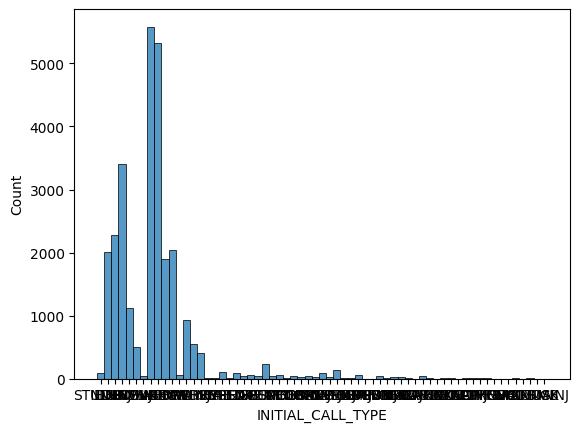

In [21]:
sns.histplot(data = ems_cleandata, x = 'INITIAL_CALL_TYPE')

<Axes: xlabel='DISPATCH_RESPONSE_SECONDS_QY', ylabel='Density'>

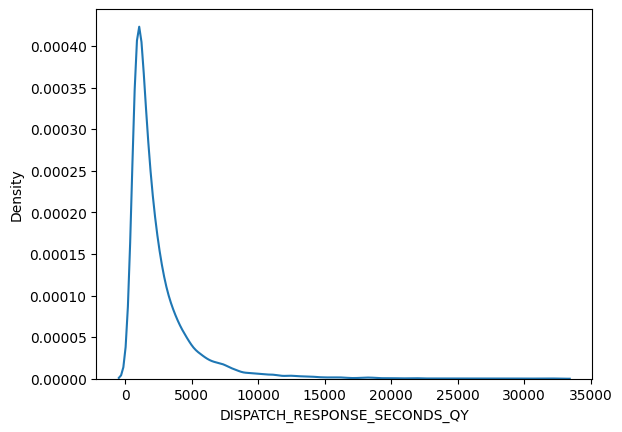

In [22]:
sns.kdeplot(data = ems_cleandata, x = 'DISPATCH_RESPONSE_SECONDS_QY')

In [23]:
ems_cleandata.columns

Index(['INCIDENT_DATETIME', 'INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE',
       'FINAL_CALL_TYPE', 'FINAL_SEVERITY_LEVEL_CODE',
       'FIRST_ASSIGNMENT_DATETIME', 'VALID_DISPATCH_RSPNS_TIME_INDC',
       'DISPATCH_RESPONSE_SECONDS_QY', 'FIRST_ACTIVATION_DATETIME',
       'FIRST_ON_SCENE_DATETIME', 'VALID_INCIDENT_RSPNS_TIME_INDC',
       'INCIDENT_RESPONSE_SECONDS_QY', 'INCIDENT_TRAVEL_TM_SECONDS_QY',
       'FIRST_TO_HOSP_DATETIME', 'FIRST_HOSP_ARRIVAL_DATETIME',
       'INCIDENT_CLOSE_DATETIME', 'HELD_INDICATOR',
       'INCIDENT_DISPOSITION_CODE', 'BOROUGH'],
      dtype='object')

<Axes: xlabel='INITIAL_CALL_TYPE', ylabel='DISPATCH_RESPONSE_SECONDS_QY'>

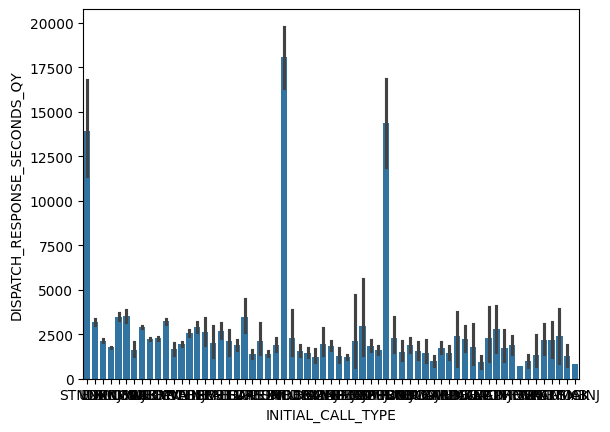

In [24]:
sns.barplot(data = ems_cleandata, x = 'INITIAL_CALL_TYPE', y = 'DISPATCH_RESPONSE_SECONDS_QY')

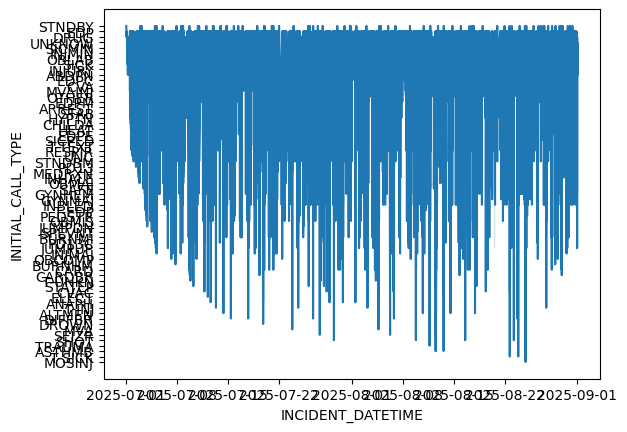

In [45]:
sns.lineplot(data=ems_cleandata, x = 'INCIDENT_DATETIME', y = 'INITIAL_CALL_TYPE');

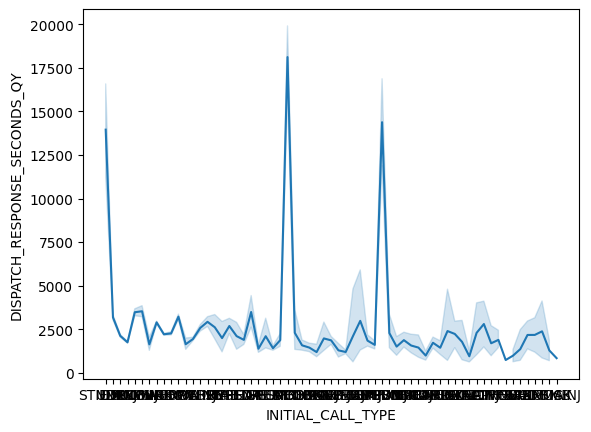

In [42]:
sns.lineplot(data=ems_cleandata, x = 'INITIAL_CALL_TYPE', y = 'DISPATCH_RESPONSE_SECONDS_QY');

<Axes: xlabel='DISPATCH_RESPONSE_SECONDS_QY', ylabel='INITIAL_CALL_TYPE'>

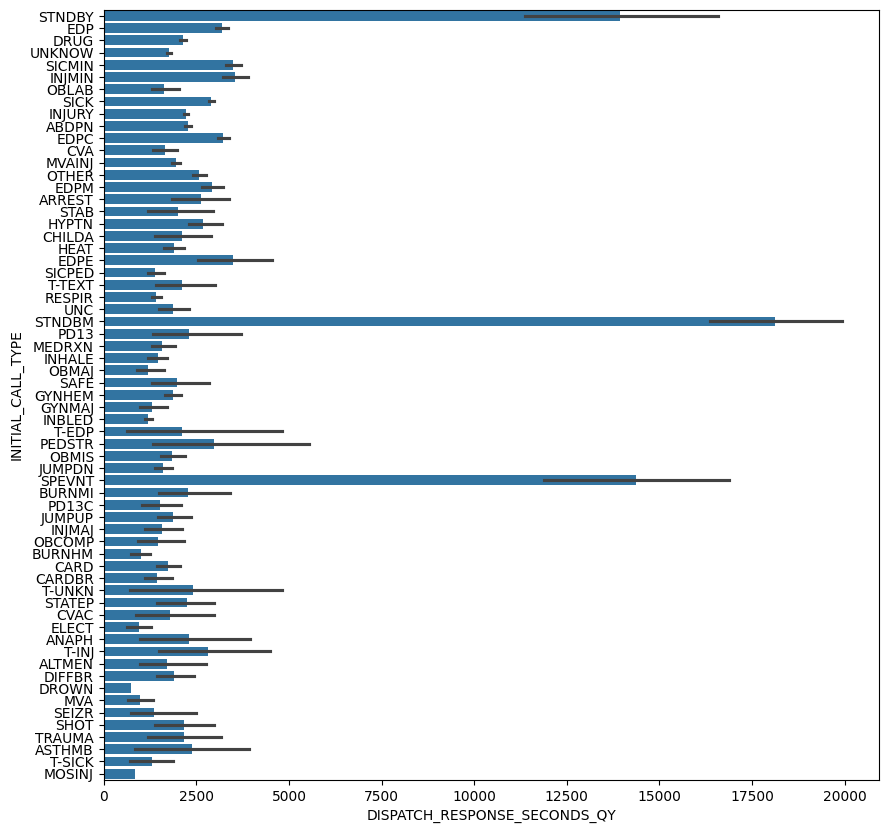

In [31]:
fig, ax = plt.subplots(figsize = (10, 10))

sns.barplot(data = ems_cleandata, y = 'INITIAL_CALL_TYPE', x = 'DISPATCH_RESPONSE_SECONDS_QY', ax=ax)